# 6 - Calcolo delle Probabilità con R

Questo notebook introduce il **calcolo delle probabilità** mediante simulazioni con R:
1. **Lancio di un dado** — campionamento casuale
2. **Lancio di due dadi** — somma di due variabili casuali e distribuzione empirica
3. **Dado e moneta** — prodotto di tre variabili casuali

---
## Carichiamo le librerie

Usiamo `ggplot2` per visualizzare le distribuzioni delle simulazioni.

In [1]:
library(ggplot2)

---
## 1. Lancio di un Dado

La funzione `sample()` permette di estrarre un campione casuale da un insieme di valori.
Simuliamo 36 lanci di un dado a 6 facce.

In [14]:
# Definiamo le facce del dado
dado <- c(1, 2, 3, 4, 5, 6)

# Lancio singolo
sample(dado, 1)

# 36 lanci con reinserimento (replace = TRUE)
lanci <- sample(dado, 36, replace = TRUE)
lanci

lanci10k <- sample(dado, 10000, replace = TRUE)

[1] 5

[1] 2 1 3 3 6 4 1 4 4 5 3 3 4 3 1 1 3 5 3 4 5 2 4 1 6 4 3 2 1 1 5 4 2 3 4 6

Warning message in geom_histogram(aes(x = lanci, ), stat = "count", col = "black", :
“Ignoring unknown parameters: `binwidth` and `bins`”


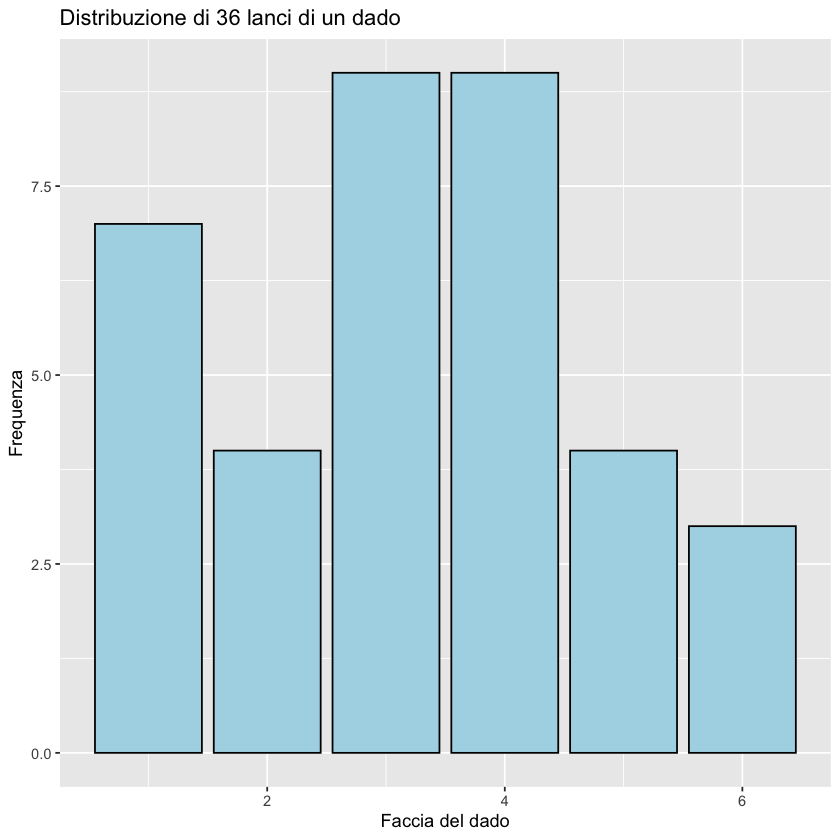

In [44]:
# Istogramma dei 36 lanci
ggplot() +
  geom_histogram(aes(x = lanci,),
                 stat = "count",
                 col = "black",
                 fill = "lightblue") +
  labs(title = "Distribuzione di 36 lanci di un dado",
       x = "Faccia del dado",
       y = "Frequenza") 

`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.


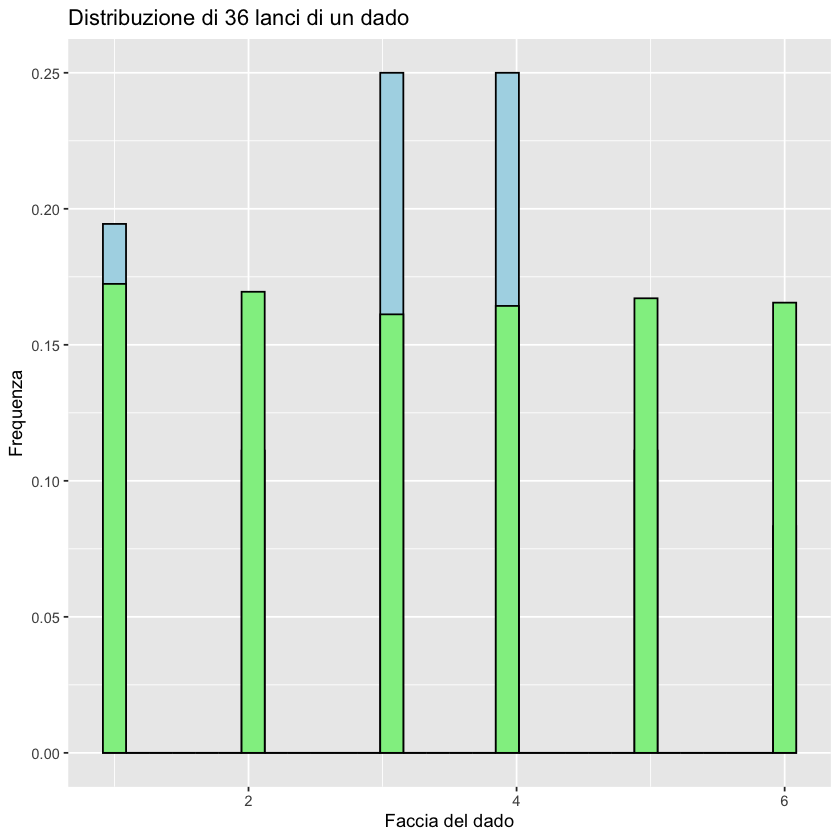

In [45]:
# Istogramma dei 36 lanci
ggplot() +
  geom_histogram(aes(x = lanci, y = stat(count / sum(count))),
                 col = "black",
                 fill = "lightblue") +
  labs(title = "Distribuzione di 36 lanci di un dado",
       x = "Faccia del dado",
       y = "Frequenza") +
  geom_histogram(aes(x = lanci10k, y = stat(count / sum(count))), 
                 col = "black",
                 fill = "lightgreen",
                 show.legend = TRUE)

---
## 2. Lancio di Due Dadi (Somma)

Simuliamo il lancio di due dadi e studiamo la distribuzione della **somma** dei due risultati.
Secondo la teoria, la distribuzione della somma di due dadi è triangolare (il 7 è il valore più probabile).

In [47]:
# Definiamo i due dadi
dado1 <- c(1, 2, 3, 4, 5, 6)
dado2 <- c(1, 2, 3, 4, 5, 6)

# Funzione per simulare il lancio di due dadi
lancio2dadi <- function(d1, d2, n) {
  somma <- sample(d1, n, replace = TRUE) + sample(d2, n, replace = TRUE)
  return(somma)
}

# 100.000 lanci di due dadi
lanci <- lancio2dadi(dado1, dado2, 100000)

Warning message in geom_histogram(aes(x = lanci, y = stat(count/sum(count))), stat = "count", :
“Ignoring unknown parameters: `binwidth` and `bins`”


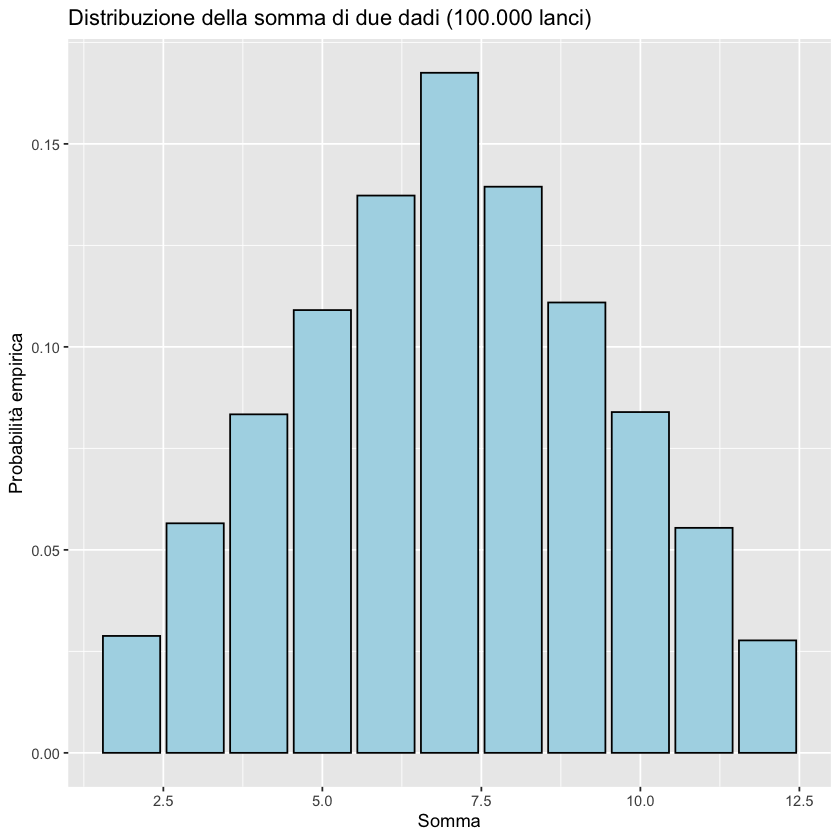

In [48]:
# Istogramma con frequenze relative (probabilità empiriche)
ggplot() +
  geom_histogram(aes(x = lanci,
                     y = stat(count / sum(count))),
                 stat = "count",
                 col = "black",
                 fill = "lightblue") +
  labs(title = "Distribuzione della somma di due dadi (100.000 lanci)",
       x = "Somma",
       y = "Probabilità empirica")

---
## 3. Dado × Dado × Moneta

Simuliamo un esperimento più complesso:
- Lanciamo due dadi e una moneta
- Calcoliamo il **prodotto** dei tre risultati
- La moneta ha valore 3 (Testa) o 6 (Croce)

In [49]:
# Definiamo dado e moneta
dado <- c(1, 2, 3, 4, 5, 6)
moneta <- c(3, 6)  # 3 = Testa, 6 = Croce

# Funzione per simulare dado × dado × moneta
dado_moneta <- function(d1, m, n) {
  molt <- sample(d1, n, replace = TRUE) *
          sample(d1, n, replace = TRUE) *
          sample(m, n, replace = TRUE)
  return(molt)
}

# 100.000 simulazioni
lanci <- dado_moneta(dado, moneta, 100000)

Warning message in geom_histogram(aes(x = lanci), stat = "count", col = "black", :
“Ignoring unknown parameters: `binwidth` and `bins`”


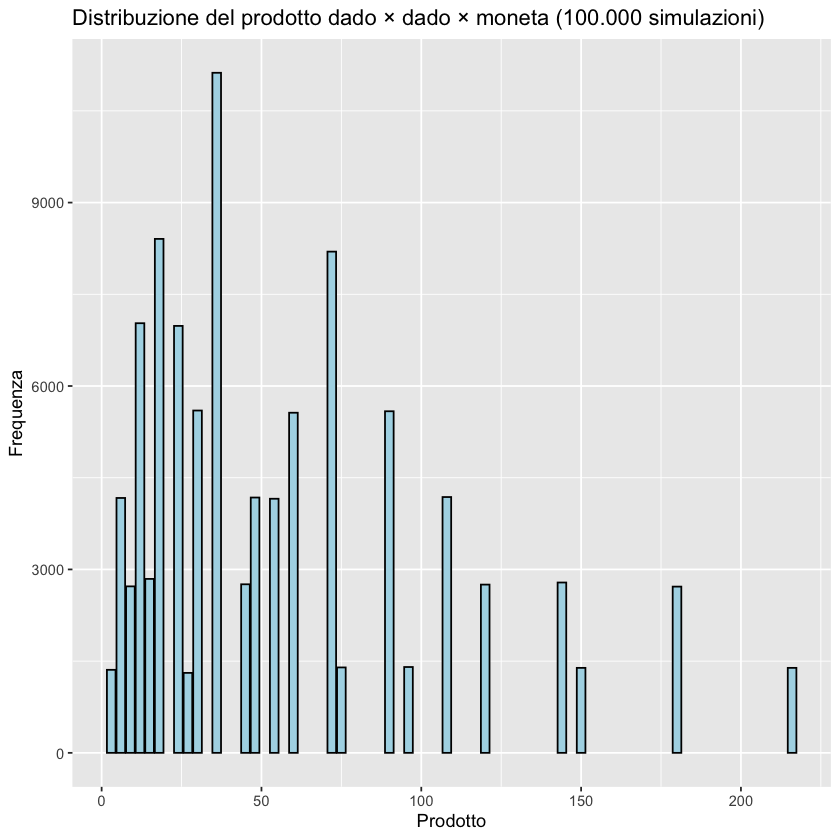

In [50]:
# Istogramma del prodotto dado × dado × moneta
ggplot() +
  geom_histogram(aes(x = lanci),
                 stat = "count",
                 col = "black",
                 fill = "lightblue") +
  labs(title = "Distribuzione del prodotto dado × dado × moneta (100.000 simulazioni)",
       x = "Prodotto",
       y = "Frequenza")

- It is __discrete__ (not continuous)

- It is __right-skewed__ (positive skew) with a long tail

- The distribution is __multi-modal__ / irregular rather than bell-shaped

**Multi-modal** means the distribution has **more than one "peak"** — that is, more than one value that occurs with relatively high frequency compared to nearby values.

Think of it like a mountain range:
- **Unimodal** (one mode): one single peak, like a bell curve (Normal distribution). Example: height of adult women.
- **Bimodal** (two modes): two peaks. Example: heights of ALL adults (men + women) — you'd see one peak around the average woman's height and another around the average man's height.
- **Multi-modal** (many modes): three or more peaks.

For the **coin × dice × dice** distribution specifically, it's multi-modal because:

1. When the coin = 3, you get certain products (e.g., 3, 6, 9, 12, 15, 18, ...)
2. When the coin = 6, you get different products (e.g., 6, 12, 18, 24, 30, ...)

These two sets of values overlap in some places (e.g., 6 appears from both coin=3×die₁×die₂=2 and coin=6×die₁×die₂=1) and don't overlap in others. This creates an irregular pattern of highs and lows in the probability mass function — multiple local peaks — hence **multi-modal**.

In simple terms: the histogram would look bumpy with several distinct "humps" rather than one smooth bell shape.